In [1]:
## Holy grail theory
## v3 - all juriks : which tools carry NON-REDUNDANT signal
##
## gain importance is biased by cardinality + collinearity (RSX/DMX/VEL families are
## mutually correlated) -> it splits credit arbitrarily and cannot answer "which tool
## is non-redundant". So ranking is done by:
##   1. permutation importance on TEST (unbiased by cardinality)
##   2. SHAP on a sample (fair credit among correlated features, + direction)
##   3. stability across walk-forward folds (keep only what's robust)
## gain is printed too, but only as a rough cross-check, NOT the answer.

In [2]:
"""
RL tradability learning -- first experiment: does PPO learn a non-trivial policy,
and does it GENERALIZE to held-out days or just MEMORIZE the tape?

Setup (agreed):
  state   : 16 features x 16-bar lookback (+ current position one-hot), no g
  actions : 0=stay-out 1=long 2=short 3=hold 4=exit, masked by position
  fills   : at NEXT bar Open (HA Open, not real OHLC -- reward is tradability, not $)
  reward  : per-bar mark-to-market in HA-space, minus 1.57 per trade. NO shaping yet.
  episode : one trading day (reset at session boundary, force-close EOD)

The reward is a proxy for TRADABILITY, not profit. The point is to learn WHERE to
act vs skip (stay-out), not to make money -- money is the detector's job later.

Expected first outcome: sits flat, or memorizes. That is the known starting point,
not failure. This experiment establishes baseline behavior and proves the loop works.

Requires: pip install stable-baselines3 sb3-contrib gymnasium --break-system-packages
"""
import sys
print(sys.executable)

import torch
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3.common.vec_env import DummyVecEnv
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())

/home/vm/venv-pt/bin/python
torch: 2.11.0+cu128
cuda: True


In [3]:
# ----------------------------- config -----------------------------
INPUT = "ha-3sec-full-rl-v4.pqt"
FEATS = ["jmaD1", "haColour", "jmaD2", "rsxLast", "rsxLastD1", "rsxLastD2", "cfbD1",
         "haBody", "candleCross", "wickAsym", "haWickTop", "haWickBott", "bodyRange",
         "dBody_3", "dWickTopR_3", "dWickBotR_3"]
PRICE_COL   = "Open"           # fills at next bar's Open (HA)
LOOKBACK    = 16
COST        = 1.57             # per-trade cost, HA price units
TEST_FRAC   = 0.20             # last fraction of days held out
N_ENVS      = 8
TOTAL_STEPS = 3_000_000        # tunable; ~<1 pass over train days, enough to see behavior
MIN_BARS    = LOOKBACK + 5

ACT_STAYOUT, ACT_LONG, ACT_SHORT, ACT_HOLD, ACT_EXIT = 0, 1, 2, 3, 4

In [5]:
%%time

# ----------------------------- data -----------------------------
df = pd.read_parquet(INPUT)

df['date'] = df['timestamp'].dt.normalize()

feat = df[FEATS].to_numpy(np.float32)
openp = df[PRICE_COL].to_numpy(np.float64)
dates = df["date"].values

tmp = pd.DataFrame({"date": dates}); tmp["idx"] = np.arange(len(tmp))
agg = tmp.groupby("date")["idx"].agg(["first", "last"])
all_days = [d for d in agg.index if agg.loc[d, "last"] - agg.loc[d, "first"] + 1 >= MIN_BARS]
all_days = sorted(all_days)
n_test = int(len(all_days) * TEST_FRAC)
train_days = all_days[:-n_test]
test_days = all_days[-n_test:]
bounds = {d: (int(agg.loc[d, "first"]), int(agg.loc[d, "last"])) for d in all_days}
print(f"{len(all_days)} usable days -> train {len(train_days)}  test {len(test_days)}")
print(f"train {train_days[0]}..{train_days[-1]}   test {test_days[0]}..{test_days[-1]}")

# normalize features on TRAIN days only
tr_mask = df["date"].isin(set(train_days)).to_numpy()
mu = feat[tr_mask].mean(0); sd = feat[tr_mask].std(0) + 1e-8
feat = (feat - mu) / sd

1158 usable days -> train 927  test 231
train 2022-01-03 00:00:00..2025-08-04 00:00:00   test 2025-08-05 00:00:00..2026-06-26 00:00:00
CPU times: user 3.62 s, sys: 5.66 s, total: 9.28 s
Wall time: 2.93 s


In [6]:
# ----------------------------- environment -----------------------------
class TradingEnv(gym.Env):
    def __init__(self, day_list):
        super().__init__()
        self.day_list = list(day_list)
        self.action_space = spaces.Discrete(5)
        self.observation_space = spaces.Box(-np.inf, np.inf,
                                            shape=(LOOKBACK * len(FEATS) + 3,), dtype=np.float32)
        self.rng = np.random.default_rng()

    def _set_day(self, d):
        self.s, self.e = bounds[d]
        self.i = self.s + LOOKBACK - 1        # first decision bar (lookback fits within day)
        self.pos = 0
        self.entry_i = -1

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        d = (options or {}).get("day") or self.rng.choice(self.day_list)
        self._set_day(d)
        return self._obs(), {}

    def _obs(self):
        w = feat[self.i - LOOKBACK + 1: self.i + 1].reshape(-1)     # (LOOKBACK*F,)
        p = np.zeros(3, np.float32); p[self.pos + 1] = 1.0          # pos in {-1,0,1} -> idx {0,1,2}
        return np.concatenate([w, p]).astype(np.float32)

    def action_masks(self):
        if self.pos == 0:
            return np.array([True, True, True, False, False])       # stay-out/long/short
        return np.array([False, False, False, True, True])          # hold/exit

    def step(self, a):
        held = self.pos                                             # position DURING this bar's move
        move = openp[self.i + 1] - openp[self.i]                    # Open[i] -> Open[i+1]
        reward = held * move
        entered = exited = 0
        if a == ACT_LONG and self.pos == 0:
            self.pos = 1; self.entry_i = self.i + 1; reward -= COST; entered = 1
        elif a == ACT_SHORT and self.pos == 0:
            self.pos = -1; self.entry_i = self.i + 1; reward -= COST; entered = 1
        elif a == ACT_EXIT and self.pos != 0:
            self.pos = 0; reward -= COST; exited = 1
        # ACT_HOLD / ACT_STAYOUT: no change, no cost

        self.i += 1
        terminated = self.i >= self.e
        if terminated and self.pos != 0:                            # force-close EOD
            reward -= COST; exited = 1; self.pos = 0
        info = {"entered": entered, "exited": exited, "in_pos": int(held != 0)}
        return self._obs(), float(reward), terminated, False, info

def make_env(day_list):
    def _init():
        return ActionMasker(TradingEnv(day_list), lambda env: env.action_masks())
    return _init

In [7]:
%%time

# ----------------------------- internal correctness check -----------------------------
# always-long over a day must equal HA buy-and-hold: sum of Open moves from entry fill to EOD.
def _check_env():
    e = TradingEnv(train_days); d = train_days[len(train_days)//2]
    e.reset(options={"day": d}); s, en = bounds[d]
    total = 0.0; done = False
    first = True
    while not done:
        a = ACT_LONG if first else ACT_HOLD
        first = False
        _, r, done, _, _ = e.step(a)
        total += r
    # independent: long fills at Open[s+LOOKBACK], holds to Open[en]; minus entry+forced-exit cost
    entry_fill = openp[s + LOOKBACK]
    bh = (openp[en] - entry_fill) - 2 * COST
    print(f"[env check] always-long PnL {total:.4f}  vs  independent HA buy&hold {bh:.4f}  "
          f"diff {abs(total-bh):.6f}")
    # always-stay-out must be exactly 0
    e.reset(options={"day": d}); tot0 = 0.0; done = False
    while not done:
        _, r, done, _, _ = e.step(ACT_STAYOUT); tot0 += r
    print(f"[env check] always-stay-out PnL {tot0:.6f}  (must be 0)")

_check_env()

[env check] always-long PnL -47.6517  vs  independent HA buy&hold -47.6517  diff 0.000000
[env check] always-stay-out PnL 0.000000  (must be 0)
CPU times: user 43.8 ms, sys: 441 μs, total: 44.2 ms
Wall time: 44 ms


In [8]:
%%time

# ----------------------------- train -----------------------------
venv = DummyVecEnv([make_env(train_days) for _ in range(N_ENVS)])
model = MaskablePPO("MlpPolicy", venv, device="auto", verbose=1,
                    n_steps=2048, batch_size=256, n_epochs=10,
                    gamma=0.99, gae_lambda=0.95, clip_range=0.2,
                    ent_coef=0.01,                 # nudge exploration so it doesn't instantly park in stay-out
                    learning_rate=3e-4, policy_kwargs=dict(net_arch=[256, 256]))
print(f"\ntraining MaskablePPO for {TOTAL_STEPS:,} steps on {N_ENVS} envs...")
model.learn(total_timesteps=TOTAL_STEPS, progress_bar=True)

Using cuda device


Output()


training MaskablePPO for 3,000,000 steps on 8 envs...
------------------------------
| time/              |       |
|    fps             | 2629  |
|    iterations      | 1     |
|    time_elapsed    | 6     |
|    total_timesteps | 16384 |
------------------------------
----------------------------------------
| time/                   |            |
|    fps                  | 1645       |
|    iterations           | 2          |
|    time_elapsed         | 19         |
|    total_timesteps      | 32768      |
| train/                  |            |
|    approx_kl            | 0.01880304 |
|    clip_fraction        | 0.346      |
|    clip_range           | 0.2        |
|    entropy_loss         | -0.851     |
|    explained_variance   | -0.0171    |
|    learning_rate        | 0.0003     |
|    loss                 | 4.42       |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.0415    |
|    value_loss           | 34.1       |
-------------------------------

CPU times: user 32min 6s, sys: 6min 24s, total: 38min 30s
Wall time: 38min 21s


In [10]:
print(model.device)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

cuda
True
NVIDIA GeForce RTX 3060


In [11]:
import torch
from tqdm import tqdm

model.policy.set_training_mode(False)
model.policy.to("cpu")          # single-obs inference is FASTER on CPU (no GPU transfer overhead)

@torch.no_grad()
def _greedy(obs, mask):
    # raw forward pass, masked argmax -- skips model.predict's per-call overhead
    o = torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0)
    dist = model.policy.get_distribution(o)
    logits = dist.distribution.logits.squeeze(0).numpy()
    logits[~mask] = -1e9
    return int(logits.argmax())

def run(policy, days):
    env = TradingEnv(days)
    tot_r = n_ent = n_pos = n_bar = 0.0
    for d in tqdm(days, desc=policy):
        obs, _ = env.reset(options={"day": d}); done = False
        while not done:
            mask = env.action_masks()
            if policy == "random":
                valid = np.where(mask)[0]; a = int(np.random.choice(valid))
            else:
                a = _greedy(obs, mask)
            obs, r, done, _, info = env.step(a)
            tot_r += r; n_ent += info["entered"]; n_pos += info["in_pos"]; n_bar += 1
    nd = len(days)
    return dict(rew_day=tot_r / nd, trades_day=n_ent / nd,
                dur=n_pos / max(n_ent, 1), pct_pos=n_pos / n_bar)

tr = run("model", train_days[-len(test_days):])
te = run("model", test_days)
rnd = run("random", test_days)

random: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 231/231 [00:34<00:00,  6.75it/s]


In [12]:
print("\n=== results (per-day) ===")
def show(name, r):
    print(f"  {name:14} reward/day {r['rew_day']:9.2f}  trades/day {r['trades_day']:6.2f}  "
          f"avg_dur {r['dur']:6.1f} bars  time_in_pos {r['pct_pos']:.1%}")
show("train (recent)", tr); show("test (held-out)", te); show("random (test)", rnd)

print("\n=== diagnosis ===")
if te["trades_day"] < 0.5 and tr["trades_day"] < 0.5:
    print("  SITS FLAT: policy learned to stay out (cost makes trading unattractive, or reward too flat).")
    print("  -> expected first result. next: reward shaping to incentivize entering tradable stretches.")
elif tr["rew_day"] > 2 * max(te["rew_day"], 0.01) and te["rew_day"] <= rnd["rew_day"] * 1.1:
    print("  MEMORIZES: strong on train, no better than random on held-out.")
    print("  -> RL overfit the tape. next: more data / regularization / simpler policy / shorter obs.")
elif te["rew_day"] > rnd["rew_day"] + abs(rnd["rew_day"]) * 0.1:
    print("  GENERALIZES (weak signal): held-out beats random. the loop works and there IS signal.")
    print("  -> justifies reward shaping (your quick-trade + give-back penalties) and later BBO fidelity.")
else:
    print("  TRADES BUT NO EDGE: test ~ random. it acts but hasn't found generalizable tradability.")
    print("  -> reward shaping is the lever; the base PnL signal alone isn't enough.")


=== results (per-day) ===
  train (recent) reward/day     51.41  trades/day 367.01  avg_dur    4.5 bars  time_in_pos 19.9%
  test (held-out) reward/day     61.62  trades/day 456.18  avg_dur    4.5 bars  time_in_pos 24.6%
  random (test)  reward/day  -7420.19  trades/day 2360.61  avg_dur    2.0 bars  time_in_pos 57.1%

=== diagnosis ===
  GENERALIZES (weak signal): held-out beats random. the loop works and there IS signal.
  -> justifies reward shaping (your quick-trade + give-back penalties) and later BBO fidelity.


In [13]:
model.save("rl_seg_v1")

In [30]:
"""
plot_day("2025-03-14") -- SC-style visual validation of the RL segmentation.

Replays the saved MaskablePPO policy over one day and renders:
  - HA candlesticks (Open/High/Low/Close)
  - jma line
  - the policy's 5 actions as distinct markers:
      long entry   green triangle-up      (below bar)
      short entry  red   triangle-down    (above bar)
      exit         black x                (at close)
      hold         faint blue dot         (at close, small)
      stay-out     faint grey dot         (at low, small)

Assumes in the notebook there is already:
  df        -- full parquet incl. Open/High/Low/Close, jma, date, and the 16 FEATS
  feat      -- normalized feature matrix used in training (same normalization!)
  bounds    -- {date: (first_idx, last_idx)}
  TradingEnv, FEATS, LOOKBACK, ACT_* constants from the env script
  model     -- loaded via: model = MaskablePPO.load("rl_seg_v1")

If replaying in a fresh kernel, rebuild feat/bounds with the SAME train-day
normalization as training, or the policy sees shifted inputs and marks garbage.
"""
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

ACTION_STYLE = {
    0: dict(name="stay-out", symbol="circle",        color="rgba(32,32,32,1)", size=5),
    1: dict(name="long",     symbol="triangle-up",   color="#00b300",                size=11),
    2: dict(name="short",    symbol="triangle-down", color="#e60000",                size=11),
    3: dict(name="hold",     symbol="circle",        color="rgba(30,100,220,0.6)",  size=5),
    4: dict(name="exit",     symbol="x",             color="#000000",                size=6),
}

def plot_day(date, jma_col="jma", show_holds=True, height=750):
    d = pd.Timestamp(date)
    if d not in bounds:
        avail = sorted(bounds.keys())
        raise ValueError(f"{date} not in data. range {avail[0]}..{avail[-1]}")
    s, e = bounds[d]

    # ---- replay policy over the day, greedy, masked ----
    env = TradingEnv([d])
    obs, _ = env.reset(options={"day": d})
    acts = np.full(e - s + 1, -1, np.int8)         # per-bar action, indexed from s
    done = False
    while not done:
        i_rel = env.i - s                          # decision bar (relative)
        mask = env.action_masks()
        a, _ = model.predict(obs, action_masks=mask, deterministic=True)
        acts[i_rel] = int(a)
        obs, r, done, _, info = env.step(int(a))

    day = df.iloc[s:e + 1]
    ts = pd.to_datetime(day["timestamp"])

    fig = make_subplots(rows=1, cols=1)
    fig.add_trace(go.Candlestick(
        x=ts, open=day["Open"], high=day["High"], low=day["Low"], close=day["Close"],
        name="HA", increasing_line_color="#26a69a", decreasing_line_color="#ef5350",
        line=dict(width=1), opacity=0.9))
    if jma_col in day.columns:
        fig.add_trace(go.Scatter(x=ts, y=day[jma_col], name="jma",
                                 line=dict(color="#0000ff", width=1.6)))
    else:
        print(f"[warn] '{jma_col}' not in df; candidates: "
              f"{[c for c in day.columns if 'jma' in c.lower()]}")

    lo, hi = day["Low"].values, day["High"].values
    pad = (hi - lo).mean() * 0.6
    for code, st in ACTION_STYLE.items():
        if not show_holds and code in (0, 3):
            continue
        m = acts == code
        if not m.any():
            continue
        if code == 1:   y = lo[m] - pad            # long entry below bar
        elif code == 2: y = hi[m] + pad            # short entry above bar
        elif code == 4: y = day["Close"].values[m] # exit at close
        elif code == 3: y = day["Close"].values[m] # hold at close
        else:           y = lo[m] - pad * 0.5      # stay-out at low
        fig.add_trace(go.Scatter(
            x=ts[m], y=y, mode="markers", name=st["name"],
            marker=dict(symbol=st["symbol"], color=st["color"], size=st["size"])))

    n_long = int((acts == 1).sum()); n_short = int((acts == 2).sum())
    n_exit = int((acts == 4).sum()); pct_in = float(np.isin(acts, (1, 2, 3)).mean())
    fig.update_layout(
        title=f"{pd.Timestamp(date).date()}   longs {n_long}  shorts {n_short}  "
              f"exits {n_exit}  in-segment {pct_in:.0%}",
        height=height, xaxis_rangeslider_visible=False,
        legend=dict(orientation="h", y=1.02, x=0),
        margin=dict(l=40, r=20, t=60, b=30))
    fig.show()
    return acts                                     # per-bar actions if you want to inspect

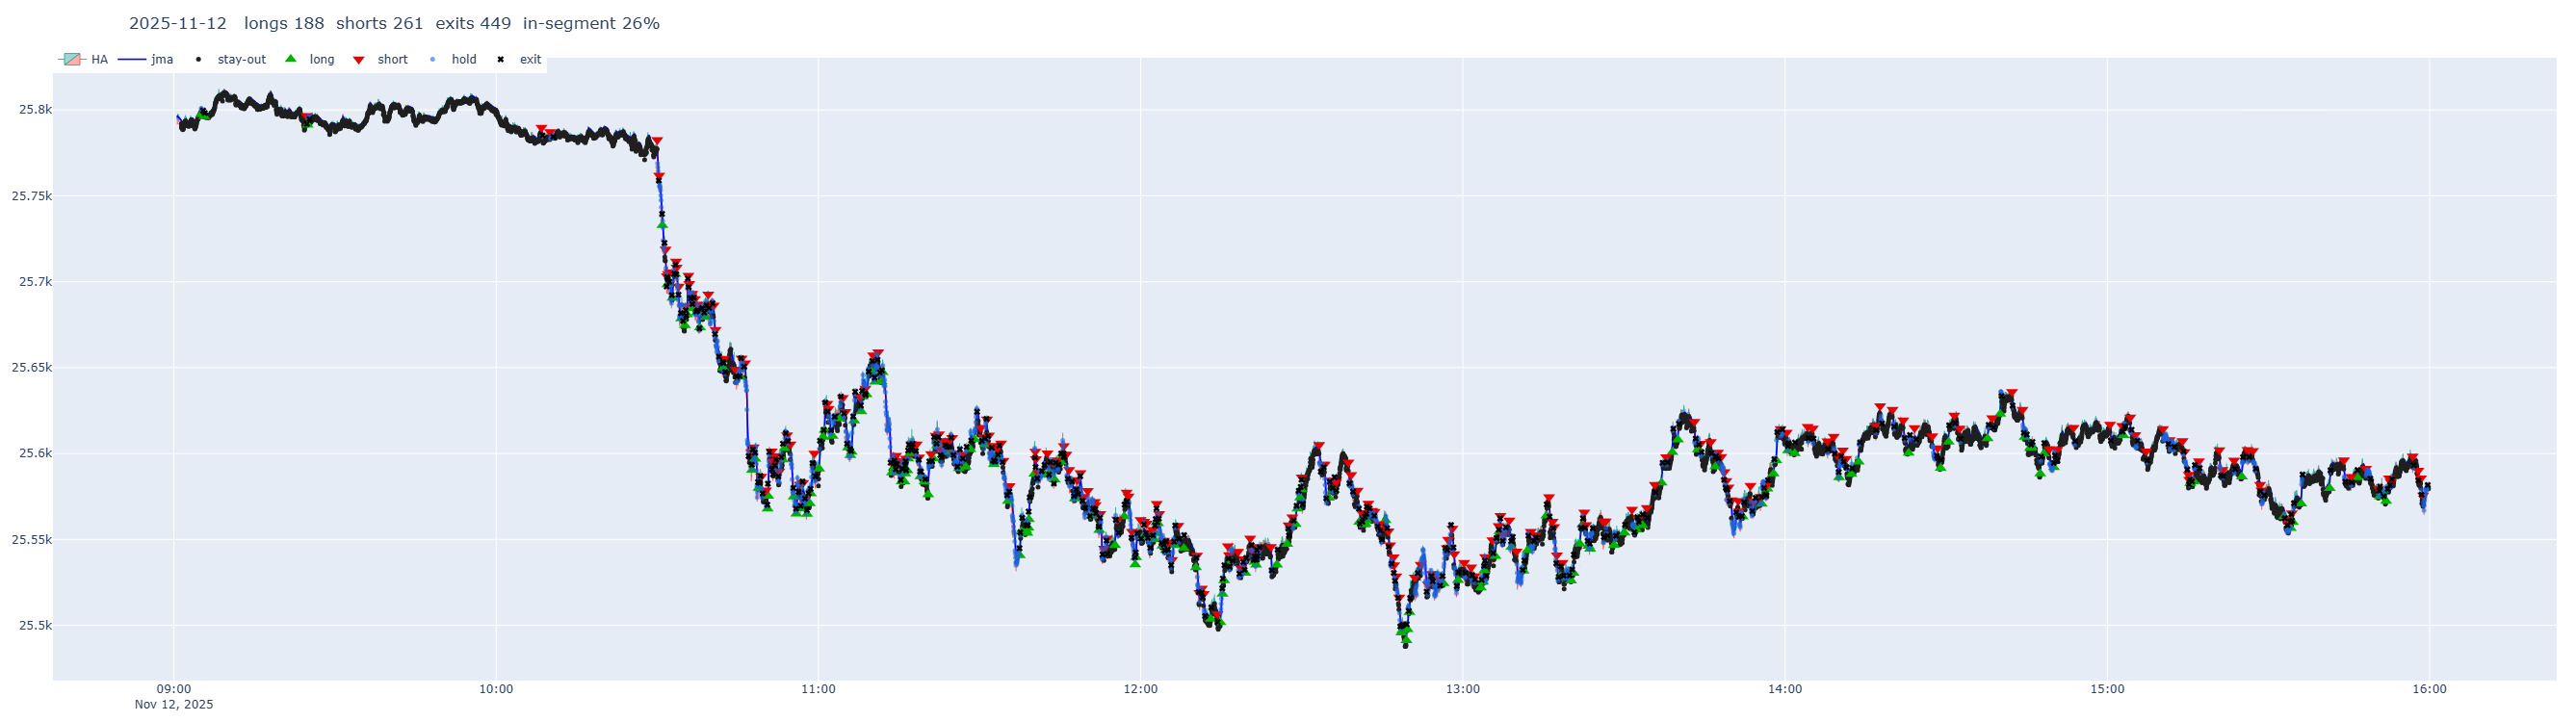

[-1 -1 -1 ...  0  0 -1]


In [31]:
acts = plot_day("2025-11-12")
print(acts)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9572766 entries, 0 to 9572765
Data columns (total 23 columns):
 #   Column       Dtype         
---  ------       -----         
 0   timestamp    datetime64[ns]
 1   Open         float64       
 2   High         float64       
 3   Low          float64       
 4   Close        float64       
 5   jma          float64       
 6   jmaD1        float64       
 7   haColour     int8          
 8   jmaD2        float64       
 9   rsxLast      float64       
 10  rsxLastD1    float64       
 11  rsxLastD2    float64       
 12  cfbD1        float64       
 13  haBody       float64       
 14  candleCross  int8          
 15  wickAsym     float64       
 16  haWickTop    float64       
 17  haWickBott   float64       
 18  bodyRange    float64       
 19  dBody_3      float64       
 20  dWickTopR_3  float64       
 21  dWickBotR_3  float64       
 22  date         datetime64[ns]
dtypes: datetime64[ns](2), float64(19), int8(2)
memory usage: 1.5 GB
